In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from matplotlib import pyplot as plt

#Warnings
import warnings
warnings.filterwarnings('ignore')

#Tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

## 1. Simple RNN

In [2]:
# Sample data
data = np.sin(np.linspace(0, 50, 500))
X = []
y = []

# Create sequences (window size = 10)
for i in range(len(data)-10):
    X.append(data[i:i+10])
    y.append(data[i+10])
X = np.array(X).reshape(-1, 10, 1)
y = np.array(y)

# RNN model
model = Sequential()
model.add(SimpleRNN(50, activation='tanh', input_shape=(10, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train
history = model.fit(X, y, epochs=20, batch_size=16, verbose=1)

2025-10-24 11:59:37.721756: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-10-24 11:59:37.721784: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-10-24 11:59:37.721793: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-10-24 11:59:37.721932: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-24 11:59:37.721941: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/20


2025-10-24 11:59:38.244566: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.1171  
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0040
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0017
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 8.7852e-04
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 5.3272e-04
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 3.2390e-04
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 1.3698e-04
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 8.8545e-05
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 6.0196e-05
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 4.4396e-05
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 5.0367e-05
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 4.1938e-05
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 5.8460e-05
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 5.6091e-05
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


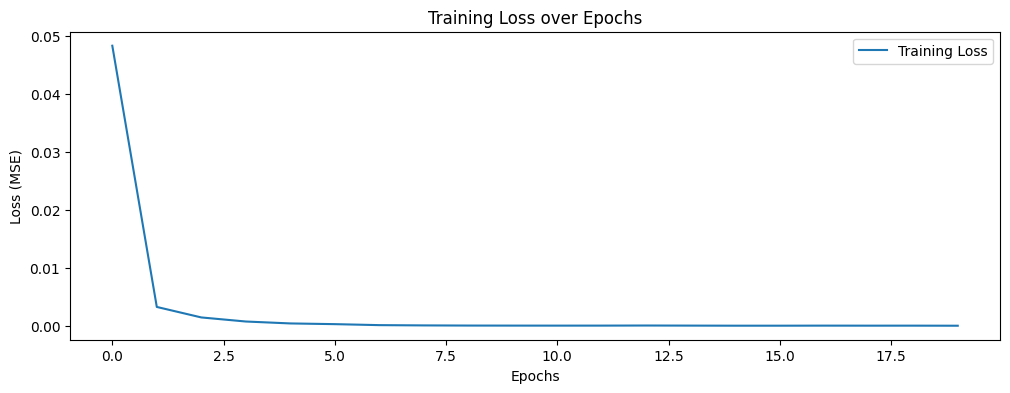

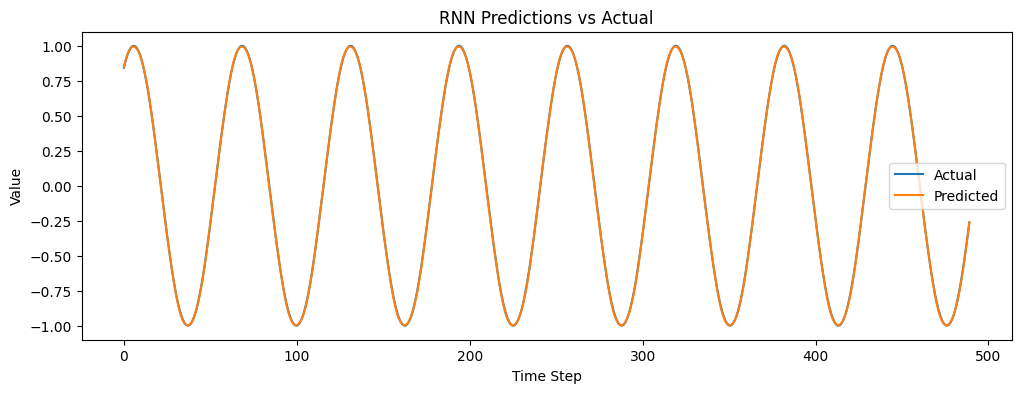

In [3]:
# Predictions
y_pred = model.predict(X)

# --- Plot Loss Curve ---
plt.figure(figsize=(12,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.title("Training Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# --- Plot Actual vs Predicted ---
plt.figure(figsize=(12,4))
plt.plot(y, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("RNN Predictions vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()

## 2. LSTM for Time series analysis

In [4]:
from tensorflow.keras.layers import LSTM

# LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='tanh', input_shape=(10, 1)))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

#Train
lstm_history = lstm_model.fit(X, y, epochs=20, batch_size=16)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3484   
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1181 
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0750 
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0389 
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0039
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.9479e-04
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.9516e-04 
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 2.7748e-04
Epoch 9/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8523e-04
Epoch 10/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2778e-04 
Epoch 11/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7.3367e-05 
Epoch 12/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.3882e-05 
Epoch 13/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.8042e-05 
Epoch 14/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7006e-05 
Epoch 15/20
31/31 ━━━━━━━━━━━━━━━

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


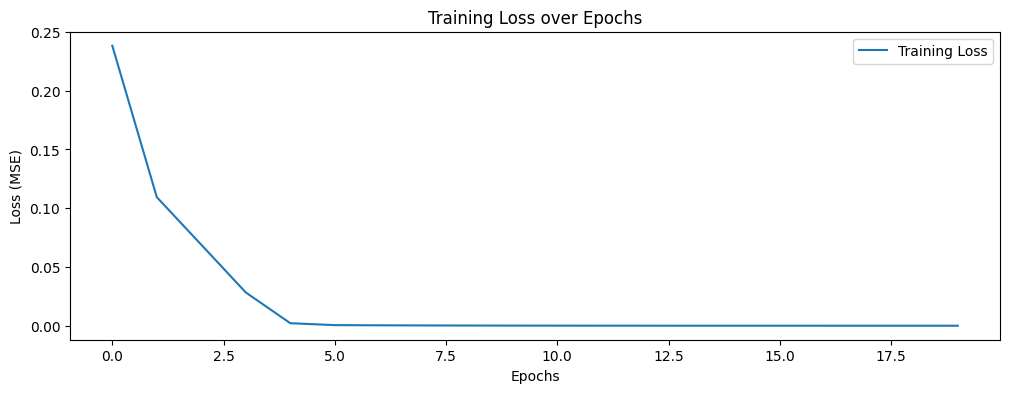

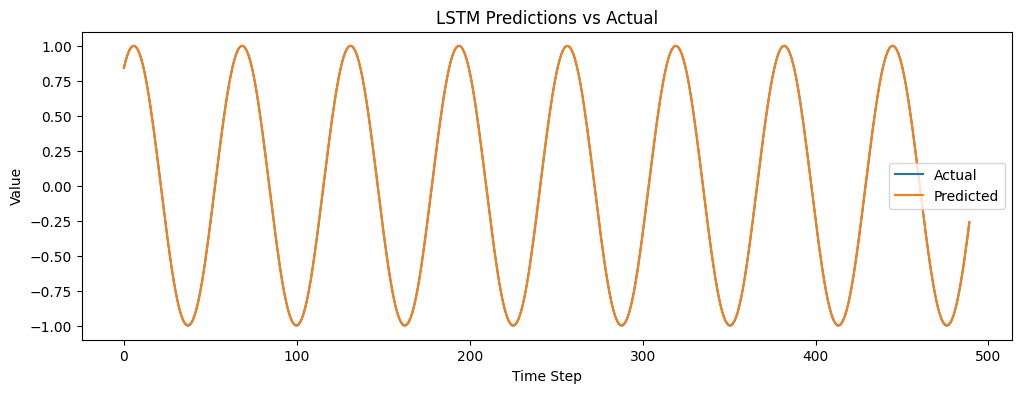

In [5]:
# --- Predictions ---
lstm_y_pred = lstm_model.predict(X)

# --- Plot Loss Curve ---
plt.figure(figsize=(12,4))
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.title("Training Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

# --- Plot Actual vs Predicted ---
plt.figure(figsize=(12,4))
plt.plot(y, label='Actual')
plt.plot(lstm_y_pred, label='Predicted')
plt.title("LSTM Predictions vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.legend()
plt.show()